# plot seasonality (july and january)

In [1]:
import intake
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import matplotlib.colors as colors
from shapely.geometry import Polygon, Point, box
from shapely import contains_xy
import time
from scipy.stats import linregress
from matplotlib.lines import Line2D
import statsmodels.api as sm


In [2]:
#import data
edso1_clt_q75_e20_jul = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_jul.nc")
edso1_clt_q75_e20_jan = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_jan.nc")

edso1_hfls_q75_e20_jul = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_q75_e20_jul.nc")
edso1_hfls_q75_e20_jan = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_q75_e20_jan.nc")

edso1_hfss_q75_e20_jul = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_q75_e20_jul.nc")
edso1_hfss_q75_e20_jan = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_q75_e20_jan.nc")

edso1_sfcwind_q75_e20_jul = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_q75_e20_jul.nc")
edso1_sfcwind_q75_e20_jan = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_q75_e20_jan.nc")

FileNotFoundError: [Errno 2] No such file or directory: b'/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_jul.nc'

In [3]:
edso1_hfss_q75_e20_jul

<xarray.Dataset>
Dimensions:                        (obs: 4196, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 474.0 476.0 ... 1.925e+06
    quantile                       float64 ...
    number                         (obs) int64 ...
Dimensions without coordinates: NbSample
Data variables: (12/42)
    amplitude                      (obs) float64 ...
    cost_association               (obs) float32 ...
    effective_area                 (obs) float32 ...
    effective_contour_height       (obs) float32 ...
    effective_contour_latitude     (obs, NbSample) float64 ...
    effective_contour_longitude    (obs, NbSample) float64 ...
    ...                             ...
    sst_mean_ed                    (obs) float64 ...
    sst_npoints_ed                 (obs) float64 ...
    sst_mean_donut                 (obs) float64 ...
    sst_npoints_donut              (obs) float64 ...
    dif_sst                        (obs) float64 ...
    id                             (obs) float64 ...
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

jul = 4196
jan = 6615

jul ac = 2292
jul c = 1904
jan c = 3333
jan ac = 3282

jul warm = 2267
jul cold = 1929
jan warm = 3562
jan cold = 3053

jul acw = 2127
jul acc = 165
jul cw = 140
jul cc = 1764
jan acw = 2275
jan acc = 1007
jan cw = 1287
jan cc = 2046

#### DOF Method

In [29]:
import numpy as np
import statsmodels.api as sm
from scipy import stats

def run_effective_regression(ds, y_name, x_name, T=7, alpha=0.05):
    """
    Full pipeline:
    - compute effective sample size (n_eff = n / T)
    - run simple linear regression y ~ x
    - compute Pearson r and R²
    - return full OLS output
    - adjust SE, t, p, CI using n_eff
    - print results rounded to 4 decimals
    """

    #data extraction
    ds_single = ds.isel(NbSample=0)
    df = ds_single.to_dataframe().reset_index()

    y = df[y_name]
    X = df[[x_name]]
    X = sm.add_constant(X)

    #effective sample size
    n = len(df)
    n_eff = n / T

    #fit OLS model
    model = sm.OLS(y, X).fit()
    ols_summary_text = model.summary().as_text()

    
    #pearson correlation and R²
    df_clean = df[[x_name, y_name]].dropna()
    r = np.corrcoef(df_clean[x_name], df_clean[y_name])[0, 1]

    R2 = r**2

    #adjust inference
    b = model.params[x_name]
    se_orig = model.bse[x_name]
    k = X.shape[1]

    se_new = se_orig * np.sqrt(n / n_eff)
    t_new = b / se_new
    df_eff = n_eff - k
    p_new = 2 * (1 - stats.t.cdf(abs(t_new), df=df_eff))

    tcrit = stats.t.ppf(1 - alpha/2, df=df_eff)
    ci_low = b - tcrit * se_new
    ci_high = b + tcrit * se_new

    #correlation significance
    t_r = r * np.sqrt((n_eff - 2) / (1 - r**2))
    p_r = 2 * (1 - stats.t.cdf(abs(t_r), df=n_eff - 2))

    #print
    print("\n===== OLS RESULTS (raw) =====")
    print(ols_summary_text)
    
    print("\n===== EFFECTIVE SAMPLE SIZE =====")
    print(f"n      = {n}")
    print(f"n_eff  = {n_eff:.4f}")
    
    print("\n===== CORRELATION =====")
    print(f"r      = {r:.4f}")
    print(f"R²     = {R2:.4f}")
    print(f"t_r    = {t_r:.4f}")
    print(f"p_r    = {p_r:.4f}")
    
    print("\n===== REGRESSION COEFFICIENT (adjusted for n_eff) =====")
    
    # CI half-width for ± notation
    ci_half_width = (ci_high - ci_low) / 2
    
    print(f"beta (± CI)    = {b:.4f} ± {ci_half_width:.4f}")
    #print(f"SE original    = {se_orig:.4f}")
    print(f"SE adjusted    = {se_new:.4f}")
    #print(f"t original     = {model.tvalues[x_name]:.4f}")
    print(f"t adjusted     = {t_new:.4f}")
    #print(f"p original     = {model.pvalues[x_name]:.4f}")
    print(f"p adjusted     = {p_new:.4f}")
    print(f"CI adjusted    = [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"df_eff         = {df_eff:.4f}")

    #return values
    return {
        "n": n,
        "n_eff": n_eff,
        "beta_original": b,
        "se_original": se_orig,
        "t_original": model.tvalues[x_name],
        "p_original": model.pvalues[x_name],
        "ci_original": model.conf_int().loc[x_name].tolist(),
        "beta": b,
        "se_adjusted": se_new,
        "t_adjusted": t_new,
        "p_adjusted": p_new,
        "ci_adjusted": (ci_low, ci_high),
        "df_eff": df_eff,
        "r": r,
        "t_r_adjusted": t_r,
        "p_r_adjusted": p_r,
        "R2": R2,
        "ols_summary": ols_summary_text,
        "model": model
    }


In [32]:
results_clt_jul = run_effective_regression(
    edso1_clt_q75_e20_jan,
    y_name="dif_clt",
    x_name="dif_sst",
    T=7
)



===== OLS RESULTS (raw) =====
                            OLS Regression Results                            
Dep. Variable:                dif_clt   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.545
Date:                Sun, 08 Feb 2026   Prob (F-statistic):             0.0598
Time:                        10:24:17   Log-Likelihood:                 12954.
No. Observations:                6615   AIC:                        -2.590e+04
Df Residuals:                    6613   BIC:                        -2.589e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007

In [33]:
results_clt_jan = run_effective_regression(
    edso1_sfcwind_q75_e20_jul,
    y_name="dif_sfcwind",
    x_name="dif_sst",
    T=7
)



===== OLS RESULTS (raw) =====
                            OLS Regression Results                            
Dep. Variable:            dif_sfcwind   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9408
Date:                Sun, 08 Feb 2026   Prob (F-statistic):              0.332
Time:                        10:24:47   Log-Likelihood:                -5688.3
No. Observations:                4196   AIC:                         1.138e+04
Df Residuals:                    4194   BIC:                         1.139e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0273

In [31]:
import numpy as np
from scipy.stats import norm

def z_test_two_slopes(beta1, se1, beta2, se2):
    """
    Z-test for difference between two independent regression slopes.

    Parameters
    ----------
    beta1, beta2 : float
        Regression coefficients from model 1 and model 2.
    se1, se2 : float
        Standard errors of the coefficients (adjusted or unadjusted).

    Returns
    -------
    dict with Z and p-value
    """

    # Z statistic
    Z = (beta1 - beta2) / np.sqrt(se1**2 + se2**2)

    # two-sided p-value
    p = 2 * (1 - norm.cdf(abs(Z)))

    return {"Z": Z, "p": p}


In [32]:
beta_jul = results_clt_jul["beta"]
se_jul   = results_clt_jul["se_adjusted"]

beta_jan = results_clt_jan["beta"]
se_jan   = results_clt_jan["se_adjusted"]


In [33]:
result = z_test_two_slopes(beta_jul, se_jul, beta_jan, se_jan)
print(result)


{'Z': -3.7951361588765926, 'p': 0.0001475624508462392}


In [34]:
round(beta_jul - beta_jan, 4)

-3.3853

#### SST Bins

In [6]:
#defining bin edges with width of 0.2° and 0 in the centre
bins = vec = np.arange(-1.5, 1.5 + 0.2, 0.2)

In [19]:
#drop nan
clt_warm_week = edso1_clt_q75_e20_jan.dropna(dim="obs", subset=["dif_sst", "dif_clt"])
clt_cold_week = edso1_clt_q75_e20_jul.dropna(dim="obs", subset=["dif_sst", "dif_clt"])

hfls_warm_week = edso1_hfls_q75_e20_jan.dropna(dim="obs", subset=["dif_sst", "dif_hfls"])
hfls_cold_week = edso1_hfls_q75_e20_jul.dropna(dim="obs", subset=["dif_sst", "dif_hfls"])

hfss_warm_week = edso1_hfss_q75_e20_jan.dropna(dim="obs", subset=["dif_sst", "dif_hfss"])
hfss_cold_week = edso1_hfss_q75_e20_jul.dropna(dim="obs", subset=["dif_sst", "dif_hfss"])

sfcwind_warm_week = edso1_sfcwind_q75_e20_jan.dropna(dim="obs", subset=["dif_sst", "dif_sfcwind"])
sfcwind_cold_week = edso1_sfcwind_q75_e20_jul.dropna(dim="obs", subset=["dif_sst", "dif_sfcwind"])

In [20]:
#calculate mean per bin
clt_warm_mean_week = (clt_warm_week["dif_clt"].groupby_bins(clt_warm_week["dif_sst"], bins).mean(dim="obs"))
clt_cold_mean_week = (clt_cold_week["dif_clt"].groupby_bins(clt_cold_week["dif_sst"], bins).mean(dim="obs"))

hfls_warm_mean_week = (hfls_warm_week["dif_hfls"].groupby_bins(hfls_warm_week["dif_sst"], bins).mean(dim="obs"))
hfls_cold_mean_week = (hfls_cold_week["dif_hfls"].groupby_bins(hfls_cold_week["dif_sst"], bins).mean(dim="obs"))

hfss_warm_mean_week = (hfss_warm_week["dif_hfss"].groupby_bins(hfss_warm_week["dif_sst"], bins).mean(dim="obs"))
hfss_cold_mean_week = (hfss_cold_week["dif_hfss"].groupby_bins(hfss_cold_week["dif_sst"], bins).mean(dim="obs"))

sfcwind_warm_mean_week = (sfcwind_warm_week["dif_sfcwind"].groupby_bins(sfcwind_warm_week["dif_sst"], bins).mean(dim="obs"))
sfcwind_cold_mean_week = (sfcwind_cold_week["dif_sfcwind"].groupby_bins(sfcwind_cold_week["dif_sst"], bins).mean(dim="obs"))

In [21]:
#calculate standard error of the mean
clt_warm_std_week = (clt_warm_week["dif_clt"].groupby_bins(clt_warm_week["dif_sst"], bins).std(dim="obs"))
clt_warm_count_week = (clt_warm_week["dif_clt"].groupby_bins(clt_warm_week["dif_sst"], bins).count(dim="obs"))
clt_warm_sem_week = clt_warm_std_week / np.sqrt(clt_warm_count_week)

clt_cold_std_week = (clt_cold_week["dif_clt"].groupby_bins(clt_cold_week["dif_sst"], bins).std(dim="obs"))
clt_cold_count_week = (clt_cold_week["dif_clt"].groupby_bins(clt_cold_week["dif_sst"], bins).count(dim="obs"))
clt_cold_sem_week = clt_cold_std_week / np.sqrt(clt_cold_count_week)

hfls_warm_std_week = (hfls_warm_week["dif_hfls"].groupby_bins(hfls_warm_week["dif_sst"], bins).std(dim="obs"))
hfls_warm_count_week = (hfls_warm_week["dif_hfls"].groupby_bins(hfls_warm_week["dif_sst"], bins).count(dim="obs"))
hfls_warm_sem_week = hfls_warm_std_week / np.sqrt(hfls_warm_count_week)

hfls_cold_std_week = (hfls_cold_week["dif_hfls"].groupby_bins(hfls_cold_week["dif_sst"], bins).std(dim="obs"))
hfls_cold_count_week = (hfls_cold_week["dif_hfls"].groupby_bins(hfls_cold_week["dif_sst"], bins).count(dim="obs"))
hfls_cold_sem_week = hfls_cold_std_week / np.sqrt(hfls_cold_count_week)

hfss_warm_std_week = (hfss_warm_week["dif_hfss"].groupby_bins(hfss_warm_week["dif_sst"], bins).std(dim="obs"))
hfss_warm_count_week = (hfss_warm_week["dif_hfss"].groupby_bins(hfss_warm_week["dif_sst"], bins).count(dim="obs"))
hfss_warm_sem_week = hfss_warm_std_week / np.sqrt(hfss_warm_count_week)

hfss_cold_std_week = (hfss_cold_week["dif_hfss"].groupby_bins(hfss_cold_week["dif_sst"], bins).std(dim="obs"))
hfss_cold_count_week = (hfss_cold_week["dif_hfss"].groupby_bins(hfss_cold_week["dif_sst"], bins).count(dim="obs"))
hfss_cold_sem_week = hfss_cold_std_week / np.sqrt(hfss_cold_count_week)

sfcwind_warm_std_week = (sfcwind_warm_week["dif_sfcwind"].groupby_bins(sfcwind_warm_week["dif_sst"], bins).std(dim="obs"))
sfcwind_warm_count_week = (sfcwind_warm_week["dif_sfcwind"].groupby_bins(sfcwind_warm_week["dif_sst"], bins).count(dim="obs"))
sfcwind_warm_sem_week = sfcwind_warm_std_week / np.sqrt(sfcwind_warm_count_week)

sfcwind_cold_std_week = (sfcwind_cold_week["dif_sfcwind"].groupby_bins(sfcwind_cold_week["dif_sst"], bins).std(dim="obs"))
sfcwind_cold_count_week = (sfcwind_cold_week["dif_sfcwind"].groupby_bins(sfcwind_cold_week["dif_sst"], bins).count(dim="obs"))
sfcwind_cold_sem_week = sfcwind_cold_std_week / np.sqrt(sfcwind_cold_count_week)



In [22]:
#get bin centeres for plotting
bin_centers = [b.mid for b in clt_warm_mean_week["dif_sst_bins"].values]
bin_centers = np.array(bin_centers)

In [23]:
mask_clt_warm = (
    np.isfinite(clt_warm_week["dif_sst"]) &
    np.isfinite(clt_warm_week["dif_clt"])
)

res_clt_warm = linregress(
    clt_warm_week["dif_sst"].values[mask_clt_warm],
    clt_warm_week["dif_clt"].values[mask_clt_warm]
)

mask_clt_cold = (
    np.isfinite(clt_cold_week["dif_sst"]) &
    np.isfinite(clt_cold_week["dif_clt"])
)

res_clt_cold = linregress(
    clt_cold_week["dif_sst"].values[mask_clt_cold],
    clt_cold_week["dif_clt"].values[mask_clt_cold]
)


In [24]:
mask_hfls_warm = (
    np.isfinite(hfls_warm_week["dif_sst"]) &
    np.isfinite(hfls_warm_week["dif_hfls"])
)

res_hfls_warm = linregress(
    hfls_warm_week["dif_sst"].values[mask_hfls_warm],
    hfls_warm_week["dif_hfls"].values[mask_hfls_warm]
)

mask_hfls_cold = (
    np.isfinite(hfls_cold_week["dif_sst"]) &
    np.isfinite(hfls_cold_week["dif_hfls"])
)

res_hfls_cold = linregress(
    hfls_cold_week["dif_sst"].values[mask_hfls_cold],
    hfls_cold_week["dif_hfls"].values[mask_hfls_cold]
)


In [25]:
mask_hfss_warm = (
    np.isfinite(hfss_warm_week["dif_sst"]) &
    np.isfinite(hfss_warm_week["dif_hfss"])
)

res_hfss_warm = linregress(
    hfss_warm_week["dif_sst"].values[mask_hfss_warm],
    hfss_warm_week["dif_hfss"].values[mask_hfss_warm]
)

mask_hfss_cold = (
    np.isfinite(hfss_cold_week["dif_sst"]) &
    np.isfinite(hfss_cold_week["dif_hfss"])
)

res_hfss_cold = linregress(
    hfss_cold_week["dif_sst"].values[mask_hfss_cold],
    hfss_cold_week["dif_hfss"].values[mask_hfss_cold]
)


In [26]:
mask_sfcwind_warm = (
    np.isfinite(sfcwind_warm_week["dif_sst"]) &
    np.isfinite(sfcwind_warm_week["dif_sfcwind"])
)

res_sfcwind_warm = linregress(
    sfcwind_warm_week["dif_sst"].values[mask_sfcwind_warm],
    sfcwind_warm_week["dif_sfcwind"].values[mask_sfcwind_warm]
)

mask_sfcwind_cold = (
    np.isfinite(sfcwind_cold_week["dif_sst"]) &
    np.isfinite(sfcwind_cold_week["dif_sfcwind"])
)

res_sfcwind_cold = linregress(
    sfcwind_cold_week["dif_sst"].values[mask_sfcwind_cold],
    sfcwind_cold_week["dif_sfcwind"].values[mask_sfcwind_cold]
)


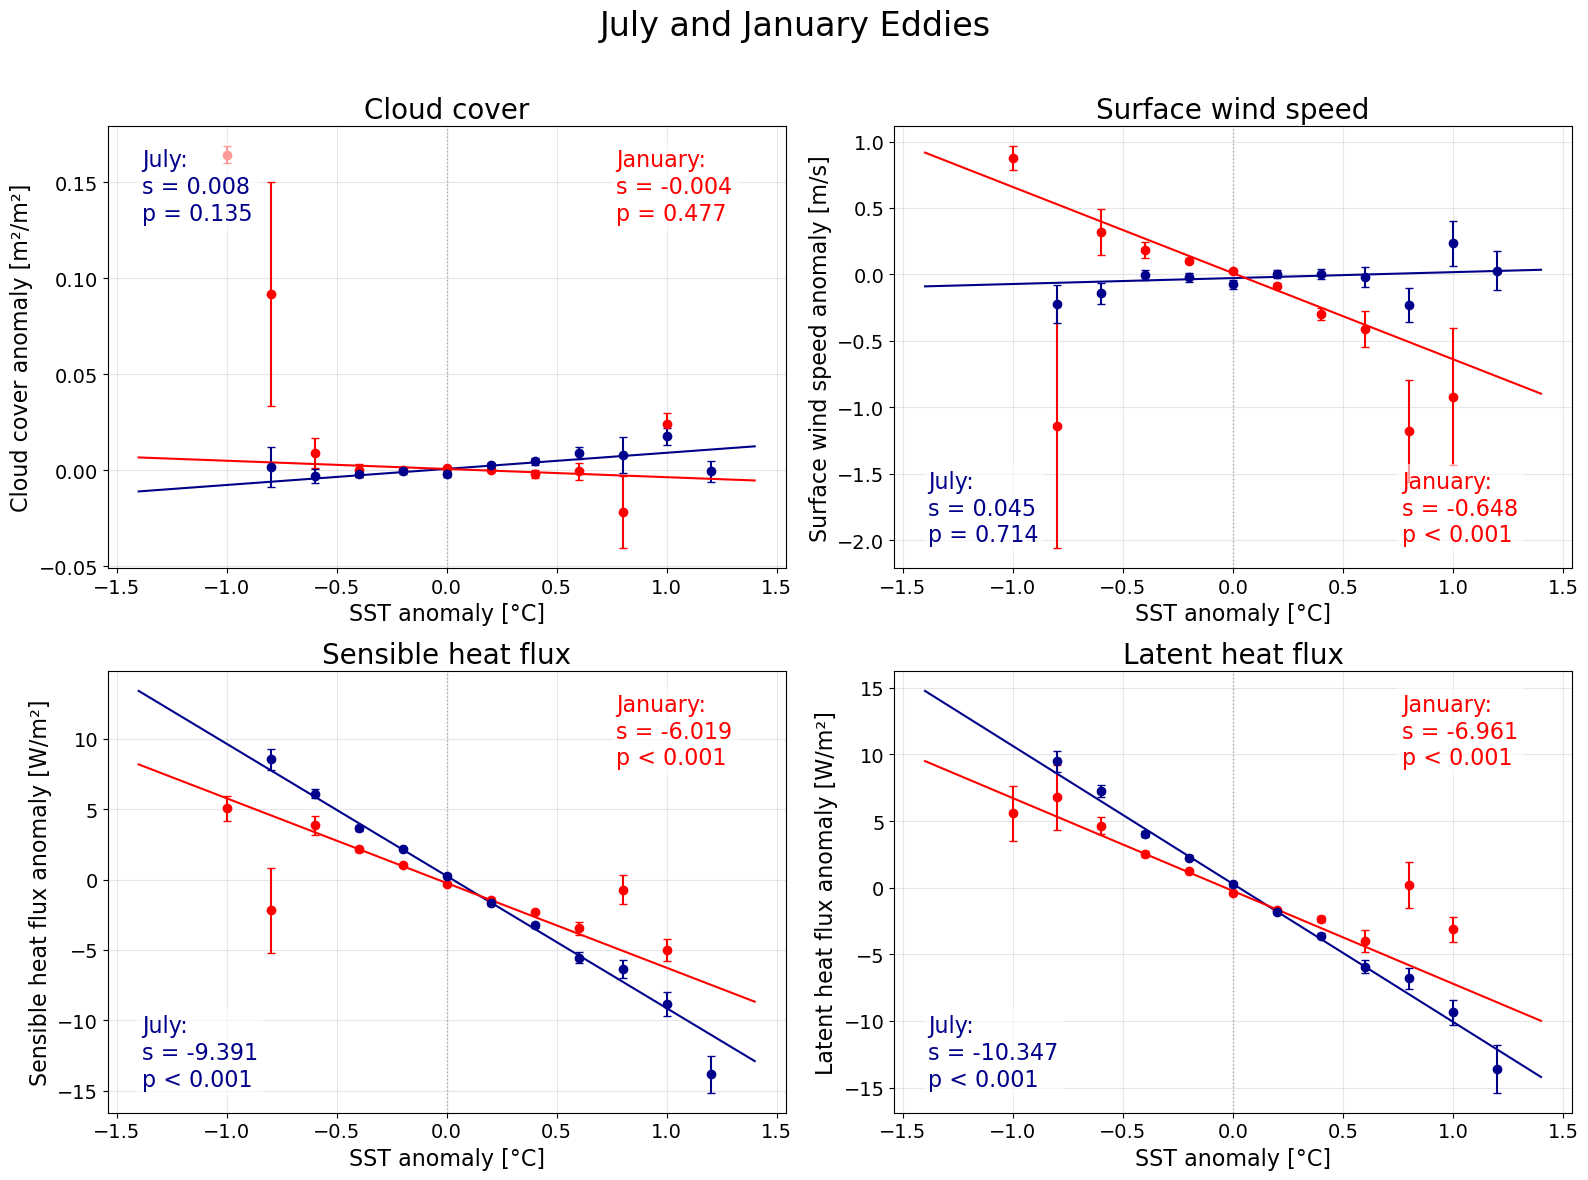

In [39]:
#plott sst bins for july and january eddies

variables = ["clt", "sfcwind", "hfss", "hfls"]
titles = [
    "Cloud cover anomaly [m²/m²]",
    "Surface wind speed anomaly [m/s]",
    "Sensible heat flux anomaly [W/m²]",
    "Latent heat flux anomaly [W/m²]"
]

pvals_jan = {
    "clt": "p = 0.477",
    "sfcwind": "p < 0.001",
    "hfss": "p < 0.001",
    "hfls": "p < 0.001"
}

pvals_jul = {
    "clt": "p = 0.135",
    "sfcwind": "p = 0.714",
    "hfss": "p < 0.001",
    "hfls": "p < 0.001"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]

    # --- jan ---
    mean_warm = globals()[f"{var}_warm_mean_week"].values
    sem_warm  = globals()[f"{var}_warm_sem_week"].values
    res_warm  = globals()[f"res_{var}_warm"]

    # --- jul ---
    mean_cold = globals()[f"{var}_cold_mean_week"].values
    sem_cold  = globals()[f"{var}_cold_sem_week"].values
    res_cold  = globals()[f"res_{var}_cold"]

    # --- Binned means ---
    ax.errorbar(
        bin_centers, mean_warm, yerr=sem_warm,
        fmt="o", capsize=3, color="red"
    )
    ax.errorbar(
        bin_centers, mean_cold, yerr=sem_cold,
        fmt="o", capsize=3, color="darkblue"
    )

    # --- Regression lines ---
    # Split x-range at 0
    x_neg = np.linspace(bin_centers.min(), bin_centers.max(), 100)
    x_pos = np.linspace(bin_centers.min(), bin_centers.max(), 100)
    
    # jul (blue):
    ax.plot(
        x_neg,
        res_cold.intercept + res_cold.slope * x_neg,
        color="darkblue", lw=1.5
    )
    
    # jan (red):
    ax.plot(
        x_pos,
        res_warm.intercept + res_warm.slope * x_pos,
        color="red", lw=1.5
    )


   # --- Text box placement ---

    if i == 0:
        # Special case: first subplot → both labels on top
        ax.text(
            0.05, 0.95,
            "July:\n"
            f"s = {res_cold.slope:.3f}\n"
            f"{pvals_jul[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="darkblue",
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    
        ax.text(
            0.75, 0.95,
            "January:\n"
            f"s = {res_warm.slope:.3f}\n"
            f"{pvals_jan[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="red",
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )


    
    elif i == 1:  # TOP ROW
    # jul (bottom-left)
        ax.text(
            0.05, 0.05,     
            "July:\n"
            f"s = {res_cold.slope:.3f}\n"
            f"{pvals_jul[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="darkblue",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    
        # Jan (bottom-right)
        ax.text(
            0.75, 0.05,
            "January:\n"
            f"s = {res_warm.slope:.3f}\n"
            f"{pvals_jan[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="red",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    else:  # BOTTOM ROW
    # jul (bottom-left)
        ax.text(
            0.05, 0.05,
            "July:\n"
            f"s = {res_cold.slope:.3f}\n"
            f"{pvals_cold[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="darkblue",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    
        # jan (top-right)
        ax.text(
            0.75, 0.95,
            "January:\n"
            f"s = {res_warm.slope:.3f}\n"
            f"{pvals_warm[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="red",
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )


    
    # --- Labels ---
    clean_title = titles[i].split("anomaly")[0].strip()
    ax.axvline(0, color="gray", lw=1, ls=":", alpha=0.6)
    ax.set_title(clean_title, fontsize=20)
    ax.set_xlabel("SST anomaly [°C]", fontsize=16)
    ax.set_ylabel(titles[i], fontsize=16)

    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=14)


plt.suptitle("July and January Eddies", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("eddy_obs_sstbins_july_january.pdf", bbox_inches="tight")
plt.show()


#### scatter plot

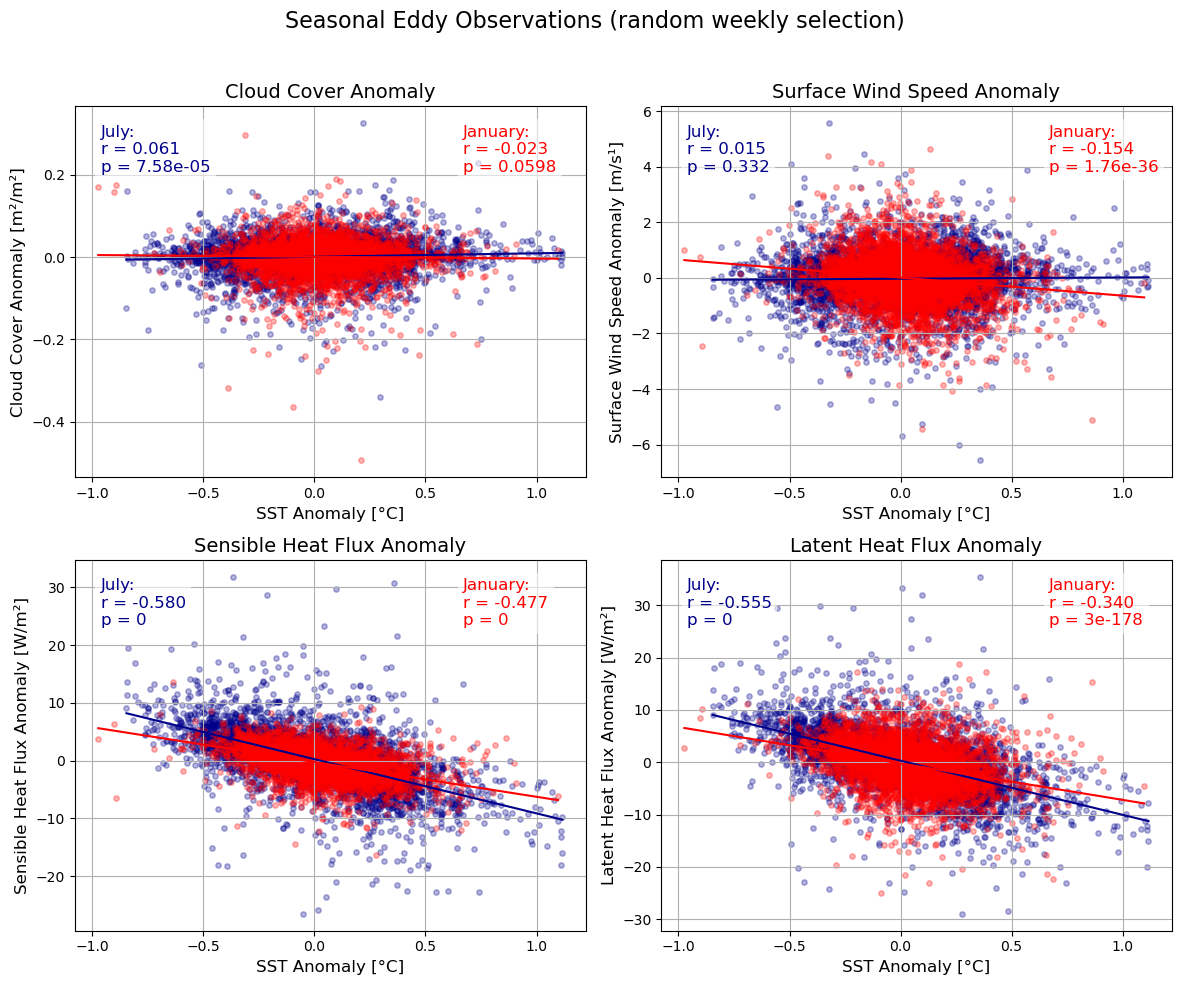

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False)


# CLOUD COVER
ax = axes[0, 0]

# July
x = edso1_clt_q75_e20_jul.dif_sst
y = edso1_clt_q75_e20_jul.dif_clt
mask = np.isfinite(x) & np.isfinite(y)
res_jul = linregress(x[mask], y[mask])

ax.scatter(x, y, color="darkblue", alpha=0.3, s=15)
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res_jul.slope * x_fit + res_jul.intercept, color="darkblue", lw=1.5)

# January
x = edso1_clt_q75_e20_jan.dif_sst
y = edso1_clt_q75_e20_jan.dif_clt
mask = np.isfinite(x) & np.isfinite(y)
res_jan = linregress(x[mask], y[mask])

ax.scatter(x, y, color="red", alpha=0.3, s=15)
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res_jan.slope * x_fit + res_jan.intercept, color="red", lw=1.5)

# JULY — left box
ax.text(
    0.05, 0.95,
    "July:\n"
    f"r = {res_jul.rvalue:.3f}\n"
    f"p = {res_jul.pvalue:.3g}",
    transform=ax.transAxes,
    fontsize=12,
    color="darkblue",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# JANUARY — right box
ax.text(
    0.76, 0.95,
    "January:\n"
    f"r = {res_jan.rvalue:.3f}\n"
    f"p = {res_jan.pvalue:.3g}",
    transform=ax.transAxes,
    fontsize=12,
    color="red",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

ax.set_xlabel("SST Anomaly [°C]", fontsize=12)
ax.set_ylabel("Cloud Cover Anomaly [m²/m²]", fontsize=12)
ax.set_title("Cloud Cover Anomaly", fontsize=14)
ax.grid(True)


# SURFACE WIND
ax = axes[0, 1]

# July
x = edso1_sfcwind_q75_e20_jul.dif_sst
y = edso1_sfcwind_q75_e20_jul.dif_sfcwind
mask = np.isfinite(x) & np.isfinite(y)
res_jul = linregress(x[mask], y[mask])

ax.scatter(x, y, color="darkblue", alpha=0.3, s=15)
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res_jul.slope * x_fit + res_jul.intercept, color="darkblue", lw=1.5)

# January
x = edso1_sfcwind_q75_e20_jan.dif_sst
y = edso1_sfcwind_q75_e20_jan.dif_sfcwind
mask = np.isfinite(x) & np.isfinite(y)
res_jan = linregress(x[mask], y[mask])

ax.scatter(x, y, color="red", alpha=0.3, s=15)
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res_jan.slope * x_fit + res_jan.intercept, color="red", lw=1.5)

# JULY — left box
ax.text(
    0.05, 0.95,
    "July:\n"
    f"r = {res_jul.rvalue:.3f}\n"
    f"p = {res_jul.pvalue:.3g}",
    transform=ax.transAxes,
    fontsize=12,
    color="darkblue",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# JANUARY — right box
ax.text(
    0.76, 0.95,
    "January:\n"
    f"r = {res_jan.rvalue:.3f}\n"
    f"p = {res_jan.pvalue:.3g}",
    transform=ax.transAxes,
    fontsize=12,
    color="red",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)



ax.set_xlabel("SST Anomaly [°C]", fontsize=12)
ax.set_ylabel("Surface Wind Speed Anomaly [m/s¹]", fontsize=12)
ax.set_title("Surface Wind Speed Anomaly", fontsize=14)
ax.grid(True)


# SENSIBLE HEAT FLUX
ax = axes[1, 0]

# July
x = edso1_hfss_q75_e20_jul.dif_sst
y = edso1_hfss_q75_e20_jul.dif_hfss
mask = np.isfinite(x) & np.isfinite(y)
res_jul = linregress(x[mask], y[mask])

ax.scatter(x, y, color="darkblue", alpha=0.3, s=15)
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res_jul.slope * x_fit + res_jul.intercept, color="darkblue", lw=1.5)

# January
x = edso1_hfss_q75_e20_jan.dif_sst
y = edso1_hfss_q75_e20_jan.dif_hfss
mask = np.isfinite(x) & np.isfinite(y)
res_jan = linregress(x[mask], y[mask])

ax.scatter(x, y, color="red", alpha=0.3, s=15)
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res_jan.slope * x_fit + res_jan.intercept, color="red", lw=1.5)

# JULY — left box
ax.text(
    0.05, 0.95,
    "July:\n"
    f"r = {res_jul.rvalue:.3f}\n"
    f"p = {res_jul.pvalue:.3g}",
    transform=ax.transAxes,
    fontsize=12,
    color="darkblue",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# JANUARY — right box
ax.text(
    0.76, 0.95,
    "January:\n"
    f"r = {res_jan.rvalue:.3f}\n"
    f"p = {res_jan.pvalue:.3g}",
    transform=ax.transAxes,
    fontsize=12,
    color="red",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

ax.set_xlabel("SST Anomaly [°C]", fontsize=12)
ax.set_ylabel("Sensible Heat Flux Anomaly [W/m²]", fontsize=12)
ax.set_title("Sensible Heat Flux Anomaly", fontsize=14)
ax.grid(True)


# LATENT HEAT FLUX
ax = axes[1, 1]

# July
x = edso1_hfls_q75_e20_jul.dif_sst
y = edso1_hfls_q75_e20_jul.dif_hfls
mask = np.isfinite(x) & np.isfinite(y)
res_jul = linregress(x[mask], y[mask])

ax.scatter(x, y, color="darkblue", alpha=0.3, s=15)
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res_jul.slope * x_fit + res_jul.intercept, color="darkblue", lw=1.5)

# January
x = edso1_hfls_q75_e20_jan.dif_sst
y = edso1_hfls_q75_e20_jan.dif_hfls
mask = np.isfinite(x) & np.isfinite(y)
res_jan = linregress(x[mask], y[mask])

ax.scatter(x, y, color="red", alpha=0.3, s=15)
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res_jan.slope * x_fit + res_jan.intercept, color="red", lw=1.5)

# JULY — left box
ax.text(
    0.05, 0.95,
    "July:\n"
    f"r = {res_jul.rvalue:.3f}\n"
    f"p = {res_jul.pvalue:.3g}",
    transform=ax.transAxes,
    fontsize=12,
    color="darkblue",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

# JANUARY — right box
ax.text(
    0.76, 0.95,
    "January:\n"
    f"r = {res_jan.rvalue:.3f}\n"
    f"p = {res_jan.pvalue:.3g}",
    transform=ax.transAxes,
    fontsize=12,
    color="red",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

ax.set_xlabel("SST Anomaly [°C]", fontsize=12)
ax.set_ylabel("Latent Heat Flux Anomaly [W/m²]", fontsize=12)
ax.set_title("Latent Heat Flux Anomaly", fontsize=14)
ax.grid(True)

# =========================
fig.suptitle("Seasonal Eddy Observations (random weekly selection)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("alleddy_observations_rand_jul_jan.pdf")
plt.show()


In [8]:
def monte_carlo_weekly_linregress(ds, var, n_iter=1000, seed=None, min_points=3):
    
    rng = np.random.default_rng(seed)

    # Time binning
    time_vals = ds['time'].values
    time_min = time_vals.min()
    week_bin = ((time_vals - time_min) / np.timedelta64(1, 'D') // 7).astype(int)
    unique_weeks = np.unique(week_bin)

    slopes = []
    intercepts = []
    rvalues = []
    pvalues = []
    stderrs = []

    # NEW: placeholders for diagnostics
    qq_residuals = None
    qq_fitted = None

    n_skipped = 0

    for _ in range(n_iter):
        selected_indices = []

        for w in unique_weeks:
            indices_in_bin = np.where(week_bin == w)[0]
            if len(indices_in_bin) == 0:
                continue
            selected_indices.append(rng.choice(indices_in_bin))

        if len(selected_indices) < min_points:
            n_skipped += 1
            continue

        ds_sample = ds.isel(obs=selected_indices)

        x = ds_sample['dif_sst'].values
        y = ds_sample[var].values

        # remove NaNs
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        if len(x) < min_points or np.std(x) == 0:
            n_skipped += 1
            continue

        res = linregress(x, y)

        if np.isnan(res.slope):
            n_skipped += 1
            continue

        # store regression results
        slopes.append(res.slope)
        intercepts.append(res.intercept)
        rvalues.append(res.rvalue)
        pvalues.append(res.pvalue)
        stderrs.append(res.stderr)

        # =========================
        # STORE ONE DIAGNOSTIC SET
        # =========================
        if qq_residuals is None:
            y_pred = res.intercept + res.slope * x
            qq_residuals = y - y_pred
            qq_fitted = y_pred

    all_results = {
        'slope': np.array(slopes),
        'intercept': np.array(intercepts),
        'rvalue': np.array(rvalues),
        'pvalue': np.array(pvalues),
        'stderr': np.array(stderrs),
    }

    results_mean = {k: np.nanmean(v) for k, v in all_results.items()}
    results_std = {k: np.nanstd(v) for k, v in all_results.items()}

    return results_mean, results_std, all_results


In [9]:
def bootstrap_ci(values, ci=95):
    """
    Percentile bootstrap confidence interval.
    """
    alpha = 100 - ci
    lower = np.percentile(values, alpha / 2)
    upper = np.percentile(values, 100 - alpha / 2)
    return lower, upper


In [10]:
mean_clt_jul, std_clt_jul, all_clt_jul = monte_carlo_weekly_linregress(edso1_clt_q75_e20_jul, "dif_clt", n_iter=1000, seed=50)
mean_clt_jan, std_clt_jan, all_clt_jan = monte_carlo_weekly_linregress(edso1_clt_q75_e20_jan, "dif_clt", n_iter=1000, seed=50)

mean_hfls_jul, std_hfls_jul, all_hfls_jul = monte_carlo_weekly_linregress(edso1_hfls_q75_e20_jul, "dif_hfls", n_iter=1000, seed=50)
mean_hfls_jan, std_hfls_jan, all_hfls_jan = monte_carlo_weekly_linregress(edso1_hfls_q75_e20_jan, "dif_hfls", n_iter=1000, seed=50)

mean_hfss_jul, std_hfss_jul, all_hfss_jul = monte_carlo_weekly_linregress(edso1_hfss_q75_e20_jul, "dif_hfss", n_iter=1000, seed=50)
mean_hfss_jan, std_hfss_jan, all_hfss_jan = monte_carlo_weekly_linregress(edso1_hfss_q75_e20_jan, "dif_hfss", n_iter=1000, seed=50)

mean_sfcwind_jul, std_sfcwind_jul, all_sfcwind_jul = monte_carlo_weekly_linregress(edso1_sfcwind_q75_e20_jul, "dif_sfcwind", n_iter=1000, seed=50)
mean_sfcwind_jan, std_sfcwind_jan, all_sfcwind_jan = monte_carlo_weekly_linregress(edso1_sfcwind_q75_e20_jan, "dif_sfcwind", n_iter=1000, seed=50)

In [11]:
slope_ci_clt_jul = bootstrap_ci(all_clt_jul['slope'], ci=95)
slope_ci_clt_jan = bootstrap_ci(all_clt_jan['slope'], ci=95)

slope_ci_hfls_jul = bootstrap_ci(all_hfls_jul['slope'], ci=95)
slope_ci_hfls_jan = bootstrap_ci(all_hfls_jan['slope'], ci=95)

slope_ci_hfss_jul = bootstrap_ci(all_hfss_jul['slope'], ci=95)
slope_ci_hfss_jan = bootstrap_ci(all_hfss_jan['slope'], ci=95)

slope_ci_sfcwind_jul = bootstrap_ci(all_sfcwind_jul['slope'], ci=95)
slope_ci_sfcwind_jan = bootstrap_ci(all_sfcwind_jan['slope'], ci=95)

In [12]:
print(f"Mean slope: {mean_clt_jul['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_clt_jul[0]:.3f}, {slope_ci_clt_jul[1]:.3f}]")
print(f"Mean slope: {mean_clt_jan['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_clt_jan[0]:.3f}, {slope_ci_clt_jan[1]:.3f}]")
print()
print(f"Mean slope: {mean_hfls_jul['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfls_jul[0]:.3f}, {slope_ci_hfls_jul[1]:.3f}]")
print(f"Mean slope: {mean_hfls_jan['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfls_jan[0]:.3f}, {slope_ci_hfls_jan[1]:.3f}]")
print()
print(f"Mean slope: {mean_hfss_jul['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfss_jul[0]:.3f}, {slope_ci_hfss_jul[1]:.3f}]")
print(f"Mean slope: {mean_hfss_jan['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_hfss_jan[0]:.3f}, {slope_ci_hfss_jan[1]:.3f}]")
print()
print(f"Mean slope: {mean_sfcwind_jul['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_sfcwind_jul[0]:.3f}, {slope_ci_sfcwind_jul[1]:.3f}]")
print(f"Mean slope: {mean_sfcwind_jan['slope']:.3f}")
print(f"95% bootstrap CI: [{slope_ci_sfcwind_jan[0]:.3f}, {slope_ci_sfcwind_jan[1]:.3f}]")

Mean slope: 0.008
95% bootstrap CI: [-0.016, 0.031]
Mean slope: -0.004
95% bootstrap CI: [-0.046, 0.036]

Mean slope: -10.305
95% bootstrap CI: [-13.165, -7.363]
Mean slope: -7.097
95% bootstrap CI: [-11.284, -2.768]

Mean slope: -9.395
95% bootstrap CI: [-11.917, -6.829]
Mean slope: -6.131
95% bootstrap CI: [-8.627, -3.325]

Mean slope: 0.054
95% bootstrap CI: [-0.470, 0.620]
Mean slope: -0.660
95% bootstrap CI: [-1.543, 0.166]
